In [617]:
import copy
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Import Dataset and Tidy

In [618]:
train_data = pd.read_csv("./data/covid.train.csv")
test_data = pd.read_csv("./data/covid.test.csv")

In [619]:
test_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


In [620]:
train_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


## Baseline 0
先用 sklearn 快速確認「資料整理 + 評估流程」都正確。

In [621]:
# 從 training dataset 中分離出 validation dataset
X = train_data.drop(columns=['id', 'tested_positive.2'])
y = train_data['tested_positive.2'] # day3 percentage
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 標準化
scaler = StandardScaler() # 建立一個「標準化器」
X_train_s = scaler.fit_transform(X_train)

# 沿用上方平均數與標準差來校正 val
X_val_s = scaler.transform(X_val)


# ------------------------------------
# baseline 0 (如果我們預測出來 day3 = day2，loss 會是多少？)
pred_b0 = X_val["tested_positive.1"].to_numpy(dtype=np.float64) 
loss_b0 = mean_squared_error(y_val, pred_b0)
print(f"MSE of baseline 0 (predict y3=y2): {loss_b0}")

MSE of baseline 0 (predict y3=y2): 1.0638112270372913


# Baseline 1
建立 Ridge MODEL（y = wx+b），alpha 是懲罰 ｗ 機制，讓 w 不要太大 -> alpha 越小，model 越接近線性模型，擬合更貼但更可能 overfit；alpha 越大，model 越保守較不容易 overfit


In [622]:
# 測試不同 alpha 的 model

best_alpha_loss = {"alpha":0, "loss":10}

for a in list(np.arange(0.01, 2.0001, 0.01)):
    model = Ridge(alpha=a)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    loss = mean_squared_error(y_val, pred)
    if loss < best_alpha_loss["loss"] and loss < loss_b0:
        best_alpha_loss["alpha"] = a
        best_alpha_loss["loss"] = loss

print(f"best alpha: {best_alpha_loss['alpha']}, MSE of baseline 1: {best_alpha_loss['loss']}")

best alpha: 0.01, MSE of baseline 1: 0.9291660509752497


# PyTorch

### helper functions

In [ ]:
# All candidate features compete in one flat SelectKBest step.
# State columns may be selected, but they are not guaranteed.

def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False


STATE_ABBR = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'FL', 'GA', 'ID',
    'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'MD', 'MA', 'MI', 'MN',
    'MS', 'MO', 'NE', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK',
    'OR', 'PA', 'RI', 'SC', 'TX', 'UT', 'VA', 'WA', 'WV', 'WI',
]
SURVEY_COLS = [
    'cli', 'ili', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'wearing_mask',
    'travel_outside_state', 'work_outside_home', 'shop', 'restaurant',
    'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed',
    'felt_isolated', 'worried_become_ill', 'worried_finances',
]
STATE_COLS = [f'state_{abbr}' for abbr in STATE_ABBR]
DAY1_TP_COL = 'd1_tested_positive'
DAY2_TP_COL = 'd2_tested_positive'
TARGET_COL = 'd3_tested_positive'
# These survey families get a small amount of explicit trend information.
# tested_positive only has d2-d1 available at inference time.
DELTA_SURVEY_FEATURES = ['cli', 'ili', 'public_transit', 'travel_outside_state']
# SELECT_K controls how many columns survive the flat SelectKBest step.
# Every candidate feature competes directly.
SELECT_K = 16
TRAIN_SEEDS = [2025, 2026, 2027]
FINAL_SEEDS = [2025, 2026, 2027]
# Keep OOF small so the notebook stays easy to follow and the runtime stays reasonable.
OOF_SPLITS = 3
# Gate parameters are chosen by a tiny grid search so the last blend stays easy to read.
GATE_DELTA_GRID = [-2.0, -1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0] # 看到變化時，反應有多強
GATE_BIAS_GRID = [-1.0, 0.0, 1.0] # 沒看到特別變化時，先站在哪一邊
# A small k-bag keeps feature selection from being too brittle.
K_BAG_VALUES = [13, 14, 15, 16, 17, 18, 19]
K_BAG_LABEL = '13_14_15_16_17_18_19'


def rename_covid_columns(df, has_day3_target: bool):
    renamed = ['id'] + STATE_COLS
    for day in (1, 2, 3):
        renamed.extend([f'd{day}_{name}' for name in SURVEY_COLS])
        if day < 3 or has_day3_target:
            renamed.append(f'd{day}_tested_positive')
    out = df.copy()
    out.columns = renamed
    return out


def state_ids(df):
    return df[STATE_COLS].to_numpy(dtype=np.float32).argmax(axis=1)


def split_state_timewise(df, val_frac=0.2, min_val_per_state=10):
    sids = state_ids(df)
    tr_idx = []
    va_idx = []
    for s in range(len(STATE_COLS)):
        idx = np.flatnonzero(sids == s)
        if len(idx) == 0:
            continue
        val_count = max(min_val_per_state, int(round(len(idx) * val_frac)))
        val_count = min(val_count, len(idx) - 1)
        tr_idx.extend(idx[:-val_count].tolist())
        va_idx.extend(idx[-val_count:].tolist())
    return df.iloc[tr_idx].copy(), df.iloc[va_idx].copy()


def scale_column(train_df, val_df, col):
    scaler = StandardScaler()
    train_s = scaler.fit_transform(train_df[[col]]).astype(np.float32)
    val_s = scaler.transform(val_df[[col]]).astype(np.float32)
    return scaler, train_s, val_s


def select_top_k_columns(train_df, y_train, candidate_cols, k):
    k = min(int(k), len(candidate_cols))
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(train_df[candidate_cols], y_train)
    return [col for col, keep in zip(candidate_cols, selector.get_support()) if keep]


def scale_selected_columns(train_df, val_df, selected_cols):
    scaler = StandardScaler()
    train_s = scaler.fit_transform(train_df[selected_cols]).astype(np.float32)
    val_s = scaler.transform(val_df[selected_cols]).astype(np.float32)
    return train_s, val_s


def add_delta_features(df):
    out = df.copy()
    # tested_positive only has a day2-day1 delta at inference time.
    out['delta_d2_d1_tested_positive'] = out[DAY2_TP_COL] - out[DAY1_TP_COL]
    for name in DELTA_SURVEY_FEATURES:
        d1_col = f'd1_{name}'
        d2_col = f'd2_{name}'
        d3_col = f'd3_{name}'
        out[f'delta_d2_d1_{name}'] = out[d2_col] - out[d1_col]
        out[f'delta_d3_d2_{name}'] = out[d3_col] - out[d2_col]
    return out


def make_tensor_loader(X_s, y, batch_size: int, shuffle: bool, seed: int):
    dataset = TensorDataset(
        torch.tensor(X_s, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).reshape(-1, 1),
    )
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
    )


class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden=64, dropout=0.15, depth=2):
        super().__init__()
        layers = []
        dim = input_dim
        for _ in range(max(1, depth)):
            layers.extend([
                nn.Linear(dim, hidden),
                nn.LayerNorm(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            dim = hidden
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def evaluate_mse(model, loader, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds.append(model(xb))
            targets.append(yb)
    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    return F.mse_loss(pred, target).item()


@torch.no_grad()
def predict_numpy(model, X_s, device, batch_size=256):
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.tensor(X_s, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(device)).cpu().numpy())
    return np.vstack(preds).reshape(-1)


def train_simple_mlp(
    model,
    train_loader,
    train_eval_loader,
    val_loader,
    device,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-3,
    patience=40,
    log_every=25,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5,
    )

    best_state = None
    best_epoch = 0
    best_val = float('inf')
    bad_count = 0
    train_hist = []
    val_hist = []

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_mse = evaluate_mse(model, train_eval_loader, device)
        val_mse = evaluate_mse(model, val_loader, device)
        train_hist.append(train_mse)
        val_hist.append(val_mse)
        scheduler.step(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_count = 0
        else:
            bad_count += 1
            if bad_count >= patience:
                print(f'Early stopping at epoch {epoch}. Best epoch = {best_epoch}, best va_mse = {best_val:.4f}')
                break

        if epoch <= 5 or epoch % log_every == 0 or val_mse <= best_val + 1e-8:
            print(f'epoch {epoch}: tr_mse={train_mse:.4f}, va_mse={val_mse:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_hist, val_hist, best_epoch, best_val


def fit_full_mlp(
    model,
    train_loader,
    device,
    epochs=200,
    lr=1e-3,
    weight_decay=1e-3,
    log_every=25,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.item()) * len(xb)
            total_n += len(xb)

        train_mse = total_loss / max(total_n, 1)
        if epoch <= 5 or epoch % log_every == 0 or epoch == epochs:
            print(f'final epoch {epoch}/{epochs}: train_mse={train_mse:.4f}')

    return model


def train_one_run(
    X_train_s,
    y_train,
    X_val_s,
    y_val,
    seed,
    device,
    hidden=64,
    depth=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=300,
    patience=40,
    batch_size=64,
):
    set_seed(seed)
    train_loader = make_tensor_loader(X_train_s, y_train, batch_size=batch_size, shuffle=True, seed=seed)
    train_eval_loader = make_tensor_loader(X_train_s, y_train, batch_size=256, shuffle=False, seed=seed)
    val_loader = make_tensor_loader(X_val_s, y_val, batch_size=256, shuffle=False, seed=seed)

    model = SimpleMLP(input_dim=X_train_s.shape[1], hidden=hidden, dropout=dropout, depth=depth)
    model, train_hist, val_hist, best_epoch, best_val = train_simple_mlp(
        model,
        train_loader=train_loader,
        train_eval_loader=train_eval_loader,
        val_loader=val_loader,
        device=device,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        patience=patience,
    )

    val_pred = predict_numpy(model, X_val_s, device)
    return {
        'seed': seed,
        'model': model,
        'train_hist': train_hist,
        'val_hist': val_hist,
        'best_epoch': best_epoch,
        'best_val': best_val,
        'val_pred': val_pred,
    }


def fit_seed_ensemble(
    X_train_s,
    y_train,
    X_val_s,
    y_val,
    seed_list,
    device,
    hidden=64,
    depth=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=300,
    patience=40,
    batch_size=64,
):
    runs = []
    val_preds = []
    for seed in seed_list:
        run = train_one_run(
            X_train_s=X_train_s,
            y_train=y_train,
            X_val_s=X_val_s,
            y_val=y_val,
            seed=seed,
            device=device,
            hidden=hidden,
            depth=depth,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            patience=patience,
            batch_size=batch_size,
        )
        runs.append(run)
        val_preds.append(run['val_pred'])
        print(f"seed {seed}: best_epoch={run['best_epoch']}, best_val={run['best_val']:.4f}")

    ensemble_val_pred = np.mean(np.stack(val_preds, axis=0), axis=0)
    ensemble_val_uncertainty = np.std(np.stack(val_preds, axis=0), axis=0).astype(np.float32)
    ensemble_val_mse = mean_squared_error(y_val, ensemble_val_pred)
    avg_best_epoch = float(np.mean([run['best_epoch'] for run in runs])) if runs else 0.0
    return runs, ensemble_val_pred, ensemble_val_uncertainty, ensemble_val_mse, avg_best_epoch


def make_state_timewise_oof_folds(df, n_splits=3, seed=2025):
    n_splits = max(2, int(n_splits))
    rng = np.random.default_rng(seed)
    sids = state_ids(df)
    all_idx = np.arange(len(df), dtype=np.int64)
    folds = []

    # Shuffle rows inside each state first, then split them into equal-sized pieces.
    # This keeps every fold state-balanced without relying on the original row order.
    shuffled_state_chunks = {}
    for s in range(len(STATE_COLS)):
        state_idx = np.flatnonzero(sids == s)
        if len(state_idx) == 0:
            continue
        shuffled_state_chunks[s] = np.array_split(rng.permutation(state_idx), n_splits)

    for fold_id in range(n_splits):
        hold_idx = []
        for s in range(len(STATE_COLS)):
            if s not in shuffled_state_chunks:
                continue
            hold_idx.extend(shuffled_state_chunks[s][fold_id].tolist())

        hold_idx = np.array(sorted(set(hold_idx)), dtype=np.int64)
        fit_idx = np.setdiff1d(all_idx, hold_idx, assume_unique=False)
        folds.append((fit_idx, hold_idx))

    return folds


def fit_oof_seed_ensemble(
    train_df,
    y_train,
    selected_cols,
    seed_list,
    device,
    n_splits=3,
    hidden=64,
    depth=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=300,
    patience=40,
    batch_size=64,
):
    # Lightweight OOF:
    # keep the selected columns fixed, then rotate the held-out fold so each row
    # gets one prediction from a model that did not see it during training.
    oof_pred = np.zeros(len(train_df), dtype=np.float32)
    oof_uncertainty = np.zeros(len(train_df), dtype=np.float32)
    fold_best_epochs = []
    folds = make_state_timewise_oof_folds(train_df, n_splits=n_splits)

    for fold_id, (fit_idx, hold_idx) in enumerate(folds, start=1):
        fold_train_df = train_df.iloc[fit_idx].copy()
        fold_val_df = train_df.iloc[hold_idx].copy()
        y_fold_train = y_train[fit_idx]
        y_fold_val = y_train[hold_idx]

        X_fold_train_s, X_fold_val_s = scale_selected_columns(
            fold_train_df,
            fold_val_df,
            selected_cols,
        )

        fold_seed_preds = []
        print(f'OOF fold {fold_id}/{n_splits}: train rows = {len(fit_idx)}, val rows = {len(hold_idx)}')
        for seed in seed_list:
            run = train_one_run(
                X_train_s=X_fold_train_s,
                y_train=y_fold_train,
                X_val_s=X_fold_val_s,
                y_val=y_fold_val,
                seed=seed,
                device=device,
                hidden=hidden,
                depth=depth,
                dropout=dropout,
                lr=lr,
                weight_decay=weight_decay,
                epochs=epochs,
                patience=patience,
                batch_size=batch_size,
            )
            fold_seed_preds.append(run['val_pred'])
            fold_best_epochs.append(run['best_epoch'])
            print(f"  seed {seed}: best_epoch={run['best_epoch']}, best_val={run['best_val']:.4f}")

        fold_pred_stack = np.stack(fold_seed_preds, axis=0)
        fold_pred = np.mean(fold_pred_stack, axis=0)
        fold_uncertainty = np.std(fold_pred_stack, axis=0).astype(np.float32)
        oof_pred[hold_idx] = fold_pred
        oof_uncertainty[hold_idx] = fold_uncertainty
        fold_mse = mean_squared_error(y_fold_val, fold_pred)
        print(f'OOF fold {fold_id}: ensemble_mse={fold_mse:.4f}')

    oof_mse = mean_squared_error(y_train, oof_pred)
    avg_best_epoch = float(np.mean(fold_best_epochs)) if fold_best_epochs else 0.0
    return oof_pred, oof_uncertainty, oof_mse, avg_best_epoch


def fit_cv_seed_ensemble_for_submission(
    train_df,
    y_train,
    test_df,
    selected_cols,
    seed_list,
    device,
    n_splits=3,
    hidden=64,
    depth=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=300,
    patience=40,
    batch_size=64,
):
    # This is the final submission path.
    # Train one small ensemble per fold, then average the fold predictions on test.
    test_fold_preds = []
    test_member_preds = []
    fold_best_epochs = []
    folds = make_state_timewise_oof_folds(train_df, n_splits=n_splits)

    for fold_id, (fit_idx, hold_idx) in enumerate(folds, start=1):
        fold_train_df = train_df.iloc[fit_idx].copy()
        fold_val_df = train_df.iloc[hold_idx].copy()
        y_fold_train = y_train[fit_idx]
        y_fold_val = y_train[hold_idx]

        scaler = StandardScaler()
        X_fold_train_s = scaler.fit_transform(fold_train_df[selected_cols]).astype(np.float32)
        X_fold_val_s = scaler.transform(fold_val_df[selected_cols]).astype(np.float32)
        X_test_s = scaler.transform(test_df[selected_cols]).astype(np.float32)

        fold_seed_val_preds = []
        fold_seed_test_preds = []
        print(f'CV fold {fold_id}/{n_splits}: train rows = {len(fit_idx)}, val rows = {len(hold_idx)}')
        for seed in seed_list:
            run = train_one_run(
                X_train_s=X_fold_train_s,
                y_train=y_fold_train,
                X_val_s=X_fold_val_s,
                y_val=y_fold_val,
                seed=seed,
                device=device,
                hidden=hidden,
                depth=depth,
                dropout=dropout,
                lr=lr,
                weight_decay=weight_decay,
                epochs=epochs,
                patience=patience,
                batch_size=batch_size,
            )
            fold_seed_val_preds.append(run['val_pred'])
            test_member_pred = predict_numpy(run['model'], X_test_s, device)
            fold_seed_test_preds.append(test_member_pred)
            test_member_preds.append(test_member_pred)
            fold_best_epochs.append(run['best_epoch'])
            print(f"  seed {seed}: best_epoch={run['best_epoch']}, best_val={run['best_val']:.4f}")

        fold_val_pred = np.mean(np.stack(fold_seed_val_preds, axis=0), axis=0)
        fold_test_pred = np.mean(np.stack(fold_seed_test_preds, axis=0), axis=0)
        test_fold_preds.append(fold_test_pred)
        fold_mse = mean_squared_error(y_fold_val, fold_val_pred)
        print(f'CV fold {fold_id}: ensemble_mse={fold_mse:.4f}')

    test_pred = np.mean(np.stack(test_fold_preds, axis=0), axis=0)
    test_uncertainty = np.std(np.stack(test_member_preds, axis=0), axis=0).astype(np.float32)
    avg_best_epoch = float(np.mean(fold_best_epochs)) if fold_best_epochs else 0.0
    return test_pred, test_uncertainty, avg_best_epoch


def run_k_bag_split_pipeline(
    train_part_df,
    val_part_df,
    y_train_part,
    y_val_part,
    candidate_cols,
    k,
    seed_list,
    device,
    hidden,
    depth,
    dropout,
    lr,
    weight_decay,
    epochs,
    patience,
    batch_size,
):
    selected_cols = select_top_k_columns(train_part_df, y_train_part, candidate_cols, k)
    X_train_s, X_val_s = scale_selected_columns(train_part_df, val_part_df, selected_cols)
    runs, ensemble_val_pred, ensemble_val_uncertainty, ensemble_val_mse, avg_best_epoch_outer = fit_seed_ensemble(
        X_train_s=X_train_s,
        y_train=y_train_part,
        X_val_s=X_val_s,
        y_val=y_val_part,
        seed_list=seed_list,
        device=device,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=epochs,
        patience=patience,
        batch_size=batch_size,
    )
    oof_train_pred, oof_train_uncertainty, oof_train_mse, oof_avg_best_epoch = fit_oof_seed_ensemble(
        train_df=train_part_df,
        y_train=y_train_part,
        selected_cols=selected_cols,
        seed_list=seed_list,
        device=device,
        n_splits=OOF_SPLITS,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=epochs,
        patience=patience,
        batch_size=batch_size,
    )
    best_run = min(runs, key=lambda r: r['best_val'])
    return {
        'k': int(k),
        'selected_cols': selected_cols,
        'runs': runs,
        'train_hist': best_run['train_hist'],
        'val_hist': best_run['val_hist'],
        'best_epoch': best_run['best_epoch'],
        'best_val': best_run['best_val'],
        'ensemble_val_pred': ensemble_val_pred,
        'ensemble_val_mse': ensemble_val_mse,
        'oof_train_pred': oof_train_pred,
        'oof_train_mse': oof_train_mse,
        'avg_best_epoch_outer': avg_best_epoch_outer,
        'oof_avg_best_epoch': oof_avg_best_epoch,
    }


def run_k_bag_full_pipeline(
    full_train_df,
    full_test_df,
    y_full,
    candidate_cols,
    k,
    seed_list,
    device,
    hidden,
    depth,
    dropout,
    lr,
    weight_decay,
    epochs,
    patience,
    batch_size,
):
    selected_cols = select_top_k_columns(full_train_df, y_full, candidate_cols, k)
    cv_test_pred, cv_test_uncertainty, cv_avg_best_epoch = fit_cv_seed_ensemble_for_submission(
        train_df=full_train_df,
        y_train=y_full,
        test_df=full_test_df,
        selected_cols=selected_cols,
        seed_list=seed_list,
        device=device,
        n_splits=OOF_SPLITS,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=epochs,
        patience=patience,
        batch_size=batch_size,
    )
    return {
        'k': int(k),
        'selected_cols': selected_cols,
        'cv_test_pred': cv_test_pred,
        'cv_avg_best_epoch': cv_avg_best_epoch,
    }


def sample_gate_for_mlp(day1, day2, params):
    # gate_for_mlp = 1.0 means trust the MLP more.
    # gate_for_mlp = 0.0 means trust day2 more.
    day1 = np.asarray(day1, dtype=np.float32)
    day2 = np.asarray(day2, dtype=np.float32)
    signed_delta = day2 - day1
    delta_z = (signed_delta - params['delta_mean']) / (params['delta_std'] + 1e-6)
    logits = params['delta_slope'] * delta_z + params['bias']
    return 1.0 / (1.0 + np.exp(-logits))



def apply_sample_gate(mlp_pred, day1, day2, params):
    gate = sample_gate_for_mlp(day1, day2, params)
    blended = gate * np.asarray(mlp_pred, dtype=np.float32) + (1.0 - gate) * np.asarray(day2, dtype=np.float32)
    return blended, gate



def fit_sample_gate(day1, day2, mlp_pred, y_true):
    # Tiny grid search: simple enough to read, but flexible enough to adjust per sample.
    day1 = np.asarray(day1, dtype=np.float32)
    day2 = np.asarray(day2, dtype=np.float32)
    mlp_pred = np.asarray(mlp_pred, dtype=np.float32)
    y_true = np.asarray(y_true, dtype=np.float32)

    signed_delta = day2 - day1
    delta_mean = float(signed_delta.mean())
    delta_std = float(signed_delta.std())

    best = None
    best_mse = float('inf')

    for delta_slope in GATE_DELTA_GRID:
        for bias in GATE_BIAS_GRID:
            params = {
                'delta_slope': float(delta_slope),
                'bias': float(bias),
                'delta_mean': delta_mean,
                'delta_std': delta_std,
            }
            blended, _ = apply_sample_gate(mlp_pred, day1, day2, params)
            mse = mean_squared_error(y_true, blended)
            if mse < best_mse:
                best_mse = mse
                best = params

    best['mse'] = float(best_mse)
    return best


def train_full_model(
    X_train_s,
    y_train,
    X_test_s,
    seed,
    device,
    hidden=64,
    depth=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=200,
    batch_size=64,
):
    set_seed(seed)
    train_loader = make_tensor_loader(X_train_s, y_train, batch_size=batch_size, shuffle=True, seed=seed)
    model = SimpleMLP(input_dim=X_train_s.shape[1], hidden=hidden, dropout=dropout, depth=depth)
    model = fit_full_mlp(
        model,
        train_loader=train_loader,
        device=device,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
    )
    test_pred = predict_numpy(model, X_test_s, device)
    return model, test_pred




In [624]:
train_df = add_delta_features(rename_covid_columns(train_data, has_day3_target=True))
test_df = add_delta_features(rename_covid_columns(test_data, has_day3_target=False))

train_part_df, val_part_df = split_state_timewise(train_df, val_frac=0.2, min_val_per_state=10)
y_train_part = train_part_df[TARGET_COL].to_numpy(dtype=np.float32)
y_val_part = val_part_df[TARGET_COL].to_numpy(dtype=np.float32)
day1_train_part = train_part_df[DAY1_TP_COL].to_numpy(dtype=np.float32)
day2_train_part = train_part_df[DAY2_TP_COL].to_numpy(dtype=np.float32)
day1_val_part = val_part_df[DAY1_TP_COL].to_numpy(dtype=np.float32)
day2_val_part = val_part_df[DAY2_TP_COL].to_numpy(dtype=np.float32)

survey_cols = [f'd{day}_{name}' for day in (1, 2, 3) for name in SURVEY_COLS]
delta_feature_cols = [
    'delta_d2_d1_tested_positive',
    *[f'delta_d2_d1_{name}' for name in DELTA_SURVEY_FEATURES],
    *[f'delta_d3_d2_{name}' for name in DELTA_SURVEY_FEATURES],
]
selection_candidate_cols = STATE_COLS + survey_cols + delta_feature_cols + [DAY1_TP_COL, DAY2_TP_COL]

print(f'train_df shape = {train_df.shape}')
print(f'test_df shape = {test_df.shape}')
print(f'train_part rows = {len(train_part_df)}, val_part rows = {len(val_part_df)}')
print(f'selection candidate columns = {len(selection_candidate_cols)}')
print(f'state columns available = {len(STATE_COLS)}')
print(f'survey columns = {len(survey_cols)}')
print(f'delta columns = {len(delta_feature_cols)}')
print(f'day2 baseline val MSE = {mean_squared_error(y_val_part, day2_val_part):.4f}')

train_df shape = (2700, 95)
test_df shape = (893, 94)
train_part rows = 2160, val_part rows = 540
selection candidate columns = 93
state columns available = 40
survey columns = 51
day2 baseline val MSE = 1.3434


## Feature Selection

All candidate columns compete in one flat SelectKBest step.
State columns are optional, not mandatory.

In [625]:
selected_feature_cols = select_top_k_columns(
    train_part_df,
    y_train_part,
    selection_candidate_cols,
    SELECT_K,
)
selected_state_cols = [col for col in selected_feature_cols if col in STATE_COLS]
selected_survey_cols = [col for col in selected_feature_cols if col in survey_cols]
selected_delta_cols = [col for col in selected_feature_cols if col in delta_feature_cols]
selected_baseline_cols = [col for col in selected_feature_cols if col in [DAY1_TP_COL, DAY2_TP_COL]]
X_train_s, X_val_s = scale_selected_columns(train_part_df, val_part_df, selected_feature_cols)

print(f'SELECT_K = {SELECT_K}')
print(f'candidate columns = {len(selection_candidate_cols)}')
print(f'selected feature count = {len(selected_feature_cols)}')
print(f'selected state feature count = {len(selected_state_cols)}')
print(f'selected survey feature count = {len(selected_survey_cols)}')
print(f'selected delta feature count = {len(selected_delta_cols)}')
print(f'selected baseline feature count = {len(selected_baseline_cols)}')
print(f'X_train_s shape = {X_train_s.shape}')
print(f'X_val_s shape = {X_val_s.shape}')
print('selected feature columns:')
print(selected_feature_cols)
print('selected state columns:')
print(selected_state_cols)
print('selected survey columns:')
print(selected_survey_cols)
print('selected delta columns:')
print(selected_delta_cols)
print('selected baseline columns:')
print(selected_baseline_cols)

SELECT_K = 16
candidate columns = 93
selected feature count = 16
selected state feature count = 0
selected survey feature count = 14
selected baseline feature count = 2
X_train_s shape = (2160, 16)
X_val_s shape = (540, 16)
selected feature columns:
['d1_cli', 'd1_ili', 'd1_hh_cmnty_cli', 'd1_nohh_cmnty_cli', 'd2_cli', 'd2_ili', 'd2_hh_cmnty_cli', 'd2_nohh_cmnty_cli', 'd2_worried_finances', 'd3_cli', 'd3_ili', 'd3_hh_cmnty_cli', 'd3_nohh_cmnty_cli', 'd3_worried_finances', 'd1_tested_positive', 'd2_tested_positive']
selected state columns:
[]
selected survey columns:
['d1_cli', 'd1_ili', 'd1_hh_cmnty_cli', 'd1_nohh_cmnty_cli', 'd2_cli', 'd2_ili', 'd2_hh_cmnty_cli', 'd2_nohh_cmnty_cli', 'd2_worried_finances', 'd3_cli', 'd3_ili', 'd3_hh_cmnty_cli', 'd3_nohh_cmnty_cli', 'd3_worried_finances']
selected baseline columns:
['d1_tested_positive', 'd2_tested_positive']


## Train MLP and OOF

先保留一個外層 validation split 當 sanity check，再在 training part 裡做小型 OOF。
為了保持易讀性，特徵選擇先固定，OOF 先用來產生比較公平的預測，也會順便幫最後的 sample-wise signed-delta gate 學參數。
現在 gate 只看 signed delta，也就是 day2 和 day1 的差。
每一筆 training row 都會輪流當一次「沒看過的考題」。


In [626]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 2025
set_seed(seed)

hidden = 32
depth = 2
dropout = 0.015
lr = 1e-2
weight_decay = 0
epochs = 250
patience = 50
batch_size = 50

k_split_results = []
k_summary_rows = []
all_selected_features = []
for k in K_BAG_VALUES:
    k_result = run_k_bag_split_pipeline(
        train_part_df=train_part_df,
        val_part_df=val_part_df,
        y_train_part=y_train_part,
        y_val_part=y_val_part,
        candidate_cols=selection_candidate_cols,
        k=k,
        seed_list=TRAIN_SEEDS,
        device=device,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=epochs,
        patience=patience,
        batch_size=batch_size,
    )
    k_split_results.append(k_result)
    all_selected_features.extend(k_result['selected_cols'])
    k_summary_rows.append({
        'k': k_result['k'],
        'num_selected': len(k_result['selected_cols']),
        'outer_val_mse': k_result['ensemble_val_mse'],
        'oof_mse': k_result['oof_train_mse'],
        'avg_best_epoch_outer': k_result['avg_best_epoch_outer'],
        'oof_avg_best_epoch': k_result['oof_avg_best_epoch'],
        'selected_cols': ', '.join(k_result['selected_cols']),
    })
    print(
        f"k={k}: outer val MSE={k_result['ensemble_val_mse']:.4f}, "
        f"OOF MSE={k_result['oof_train_mse']:.4f}"
    )
    print(f"  selected cols = {k_result['selected_cols']}")

k_summary_df = pd.DataFrame(k_summary_rows)
feature_frequency_df = (
    pd.Series(all_selected_features)
    .value_counts()
    .rename_axis('feature')
    .reset_index(name='count')
)

print()
print('K-bag summary:')
print(k_summary_df[['k', 'num_selected', 'outer_val_mse', 'oof_mse']].to_string(index=False))
print()
print('Feature frequency across K_BAG_VALUES:')
print(feature_frequency_df.to_string(index=False))

bag_ensemble_val_pred = np.mean(np.stack([r['ensemble_val_pred'] for r in k_split_results], axis=0), axis=0)
bag_oof_train_pred = np.mean(np.stack([r['oof_train_pred'] for r in k_split_results], axis=0), axis=0)
bag_ensemble_val_mse = mean_squared_error(y_val_part, bag_ensemble_val_pred)
bag_oof_train_mse = mean_squared_error(y_train_part, bag_oof_train_pred)
avg_best_epoch_outer = float(np.mean([r['avg_best_epoch_outer'] for r in k_split_results])) if k_split_results else 0.0
oof_avg_best_epoch = float(np.mean([r['oof_avg_best_epoch'] for r in k_split_results])) if k_split_results else 0.0
reference_result = next(r for r in k_split_results if r['k'] == SELECT_K)
train_hist = reference_result['train_hist']
val_hist = reference_result['val_hist']
best_epoch = reference_result['best_epoch']
best_val = reference_result['best_val']

sample_gate_params = fit_sample_gate(
    day1=day1_train_part,
    day2=day2_train_part,
    mlp_pred=bag_oof_train_pred,
    y_true=y_train_part,
)
oof_gate_pred, oof_gate = apply_sample_gate(
    bag_oof_train_pred,
    day1_train_part,
    day2_train_part,
    sample_gate_params,
)
val_gate_pred, val_gate = apply_sample_gate(
    bag_ensemble_val_pred,
    day1_val_part,
    day2_val_part,
    sample_gate_params,
)

print(f'best single run best_epoch = {best_epoch}, best_val = {best_val:.4f}')
print(f'bagged outer split ensemble val MSE = {bag_ensemble_val_mse:.4f}')
print(f'bagged OOF train ensemble MSE = {bag_oof_train_mse:.4f}')
print(f'OOF gate MSE = {mean_squared_error(y_train_part, oof_gate_pred):.4f}')
print(f'outer gated val MSE = {mean_squared_error(y_val_part, val_gate_pred):.4f}')
print(f'gate fit MSE = {sample_gate_params["mse"]:.4f}')
print(f'gate params = {sample_gate_params}')
print(f'outer avg best epoch = {avg_best_epoch_outer:.1f}')
print(f'OOF avg best epoch = {oof_avg_best_epoch:.1f}')


epoch 1: tr_mse=39.0921, va_mse=63.3862
epoch 2: tr_mse=2.2922, va_mse=5.5838
epoch 3: tr_mse=1.4516, va_mse=3.2241
epoch 4: tr_mse=1.3783, va_mse=2.7519
epoch 5: tr_mse=2.4388, va_mse=4.0274
epoch 9: tr_mse=1.2334, va_mse=2.4547
epoch 12: tr_mse=1.3313, va_mse=1.9962
epoch 13: tr_mse=1.1511, va_mse=1.9725
epoch 18: tr_mse=1.0252, va_mse=1.7315
epoch 19: tr_mse=1.2373, va_mse=1.5323
epoch 25: tr_mse=0.9510, va_mse=1.4662
epoch 30: tr_mse=1.0333, va_mse=1.2654
epoch 48: tr_mse=0.9278, va_mse=1.2403
epoch 50: tr_mse=0.8677, va_mse=1.2492
epoch 71: tr_mse=0.8859, va_mse=1.2361
epoch 75: tr_mse=0.8404, va_mse=1.3040
epoch 100: tr_mse=0.8353, va_mse=1.2714
Early stopping at epoch 121. Best epoch = 71, best va_mse = 1.2361
seed 2025: best_epoch=71, best_val=1.2361
epoch 1: tr_mse=30.0558, va_mse=46.0930
epoch 2: tr_mse=2.3302, va_mse=5.2057
epoch 3: tr_mse=1.8022, va_mse=3.6886
epoch 4: tr_mse=1.2971, va_mse=2.9099
epoch 5: tr_mse=1.7262, va_mse=3.2800
epoch 8: tr_mse=1.3969, va_mse=2.1928
e

## Epoch Curve

這張圖只顯示其中一個 seed 的訓練過程，方便看模型有沒有正常收斂。
真正用來送分的是 k-bagged CV ensemble；最後再用 sample-wise signed-delta gate 把它和 day2 baseline 混合。


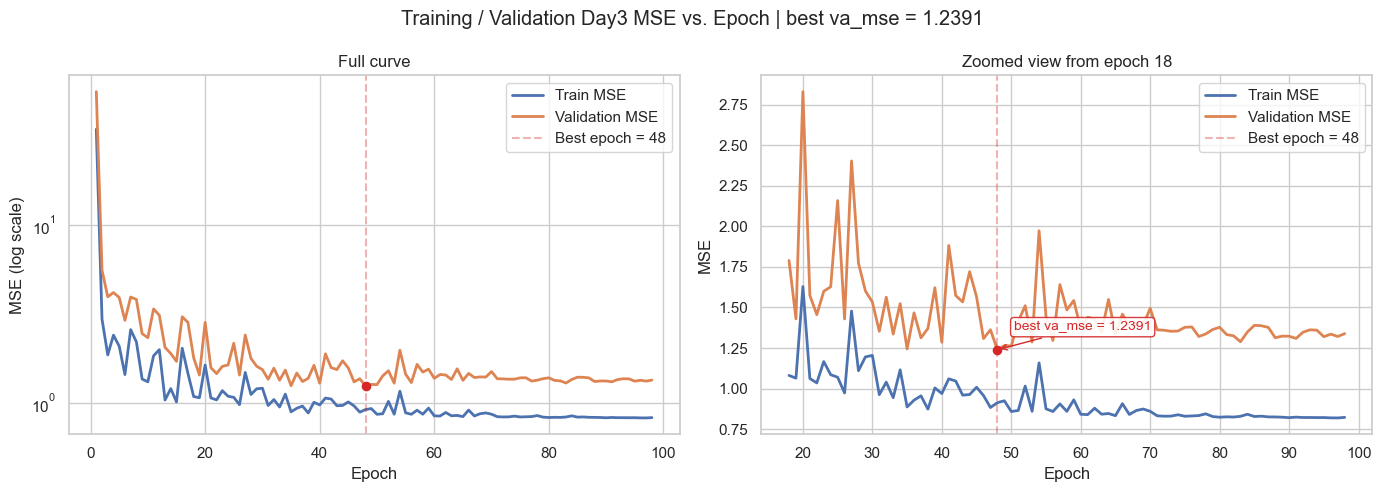

In [627]:
sns.set_theme(style='whitegrid')
epochs_ran = np.arange(1, len(train_hist) + 1)
best_epoch_plot = best_epoch if best_epoch is not None else int(np.argmin(val_hist) + 1)
best_va_mse = val_hist[best_epoch_plot - 1]

# 左圖看整體趨勢時，用 log y 軸避免前期大 MSE 把後面壓扁。
# 右圖只放大後期 epochs，方便看細部變化。
zoom_start = max(1, best_epoch_plot - 30)
zoom_mask = epochs_ran >= zoom_start

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_hist, label='Train MSE', linewidth=2)
axes[0].plot(epochs_ran, val_hist, label='Validation MSE', linewidth=2)
axes[0].axvline(best_epoch_plot, color='tab:red', linestyle='--', alpha=0.35, label=f'Best epoch = {best_epoch_plot}')
axes[0].scatter(best_epoch_plot, best_va_mse, color='tab:red', s=35, zorder=3)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (log scale)')
axes[0].set_title('Full curve')
axes[0].legend()

axes[1].plot(epochs_ran[zoom_mask], np.array(train_hist)[zoom_mask], label='Train MSE', linewidth=2)
axes[1].plot(epochs_ran[zoom_mask], np.array(val_hist)[zoom_mask], label='Validation MSE', linewidth=2)
axes[1].axvline(best_epoch_plot, color='tab:red', linestyle='--', alpha=0.35, label=f'Best epoch = {best_epoch_plot}')
axes[1].scatter(best_epoch_plot, best_va_mse, color='tab:red', s=35, zorder=3)
axes[1].annotate(
    f'best va_mse = {best_va_mse:.4f}',
    xy=(best_epoch_plot, best_va_mse),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_title(f'Zoomed view from epoch {zoom_start}')
axes[1].legend()

fig.suptitle(f'Training / Validation Day3 MSE vs. Epoch | best va_mse = {best_va_mse:.4f}')
fig.tight_layout()
plt.show()

## Final Submission

這裡先用 state-wise shuffle k-bagged CV ensemble 產生模型預測，再用 sample-wise signed-delta gate 和 day2 baseline 做最後混合。
gate 只看 signed delta，也就是 day2 和 day1 的差。


In [628]:
full_train_df = add_delta_features(rename_covid_columns(train_data, has_day3_target=True))
full_test_df = add_delta_features(rename_covid_columns(test_data, has_day3_target=False))
y_full = full_train_df[TARGET_COL].to_numpy(dtype=np.float32)

print(f'Final reference selected feature count = {len(selected_feature_cols)}')
print(f'Final reference selected state columns = {selected_state_cols}')
print(f'Final reference selected survey columns = {selected_survey_cols}')
print(f'Final reference selected delta columns = {selected_delta_cols}')
print(f'Final reference selected baseline columns = {selected_baseline_cols}')
print(f'Final reference feature columns = {selected_feature_cols}')
print(f'Final CV folds = {OOF_SPLITS}')
print(f'Final seed list = {FINAL_SEEDS}')
print(f'K bag values = {K_BAG_VALUES}')

k_full_results = []
for k in K_BAG_VALUES:
    k_result = run_k_bag_full_pipeline(
        full_train_df=full_train_df,
        full_test_df=full_test_df,
        y_full=y_full,
        candidate_cols=selection_candidate_cols,
        k=k,
        seed_list=FINAL_SEEDS,
        device=device,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=epochs,
        patience=patience,
        batch_size=batch_size,
    )
    k_full_results.append(k_result)
    print(f"k={k}: CV fold bag MSE is computed inside the helper, CV avg best epoch={k_result['cv_avg_best_epoch']:.1f}")

cv_test_pred = np.mean(np.stack([r['cv_test_pred'] for r in k_full_results], axis=0), axis=0)
cv_avg_best_epoch = float(np.mean([r['cv_avg_best_epoch'] for r in k_full_results])) if k_full_results else 0.0

day1_test = full_test_df[DAY1_TP_COL].to_numpy(dtype=np.float32)
day2_test = full_test_df[DAY2_TP_COL].to_numpy(dtype=np.float32)
gated_test_pred, test_gate = apply_sample_gate(
    cv_test_pred,
    day1_test,
    day2_test,
    sample_gate_params,
)

print(f'CV avg best epoch = {cv_avg_best_epoch:.1f}')
print(f'Test gate mean = {test_gate.mean():.4f}, std = {test_gate.std():.4f}')
final_test = np.clip(gated_test_pred, 0.0, 100.0)

submission = pd.DataFrame({
    'id': full_test_df['id'].to_numpy(),
    'tested_positive': final_test,
})
submission.to_csv(f'model_kbag{K_BAG_LABEL}_drop{dropout}_wd{weight_decay}_lr{lr}_layers{depth}_hidden{hidden}_submission.csv', index=False)

import subprocess
subprocess.run([
    'kaggle', 'competitions', 'submit',
    '-c', 'ml2021spring-hw1',
    '-f', f'model_kbag{K_BAG_LABEL}_drop{dropout}_wd{weight_decay}_lr{lr}_layers{depth}_hidden{hidden}_submission.csv',
    '-m', f'OOF state-wise shuffle sample-wise signed-delta gate / CV ensemble / k-bagging / flat SelectKBest / MultiSeed MLP',
], check=True)

print('Saved submission.csv and submitted to Kaggle with CV ensemble + sample-wise signed-delta gate + k-bagging')
submission.head()


Final reference selected feature count = 16
Final reference selected state columns = []
Final reference selected survey columns = ['d1_cli', 'd1_ili', 'd1_hh_cmnty_cli', 'd1_nohh_cmnty_cli', 'd2_cli', 'd2_ili', 'd2_hh_cmnty_cli', 'd2_nohh_cmnty_cli', 'd2_worried_finances', 'd3_cli', 'd3_ili', 'd3_hh_cmnty_cli', 'd3_nohh_cmnty_cli', 'd3_worried_finances']
Final reference selected baseline columns = ['d1_tested_positive', 'd2_tested_positive']
Final reference feature columns = ['d1_cli', 'd1_ili', 'd1_hh_cmnty_cli', 'd1_nohh_cmnty_cli', 'd2_cli', 'd2_ili', 'd2_hh_cmnty_cli', 'd2_nohh_cmnty_cli', 'd2_worried_finances', 'd3_cli', 'd3_ili', 'd3_hh_cmnty_cli', 'd3_nohh_cmnty_cli', 'd3_worried_finances', 'd1_tested_positive', 'd2_tested_positive']
Final CV folds = 3
Final seed list = [2025, 2026, 2027]
K bag values = [13, 14, 15, 16, 17, 18, 19]
CV fold 1/3: train rows = 1780, val rows = 920
epoch 1: tr_mse=75.6838, va_mse=76.0668
epoch 2: tr_mse=4.7868, va_mse=5.0472
epoch 3: tr_mse=2.1509, 

100%|██████████| 11.9k/11.9k [00:00<00:00, 13.6kB/s]


Successfully submitted to ML2021Spring-hw1Saved submission.csv and submitted to Kaggle with CV ensemble + neural signed-delta gate + k-bagging


,id,tested_positive
0,0,20.545773
1,1,2.563193
2,2,2.606132
3,3,11.235668
4,4,2.791330
